In [2]:
# load gaussian_annealing_naive_unweighted
import os
import pickle
import sys 

sys.path.append('.')
sys.path.append('..')
sys.path.append('../src')
sys.path.append('../data')
# from src.plotting import create_all_plots

# print(os.listdir('../data'))

# data = pickle.load(open('polynomial/double_well/leapfrog/cd_unweighted.pkl', 'rb'))


dict_keys(['qs', 'ps', 'weights', 'lam', 'resampling_events', 'times', 'loss_history'])
(5000, 1) particles
empirical expectation nan


/var/folders/v9/977m2z015_b794hqf_nk0q1r0000gn/T/ipykernel_10052/1493012789.py:38: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  rho = rho / np.trapz(rho, x)  # Normalize
/var/folders/v9/977m2z015_b794hqf_nk0q1r0000gn/T/ipykernel_10052/1493012789.py:61: RuntimeWarning: invalid value encountered in log
  empirical_e = compute_expectation_over_equilibrium(qs[:, 0]**2, np.log(weights))


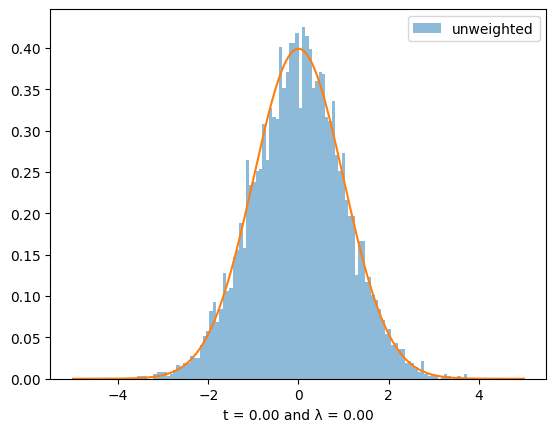

(5000, 1) particles
empirical expectation 0.9941406


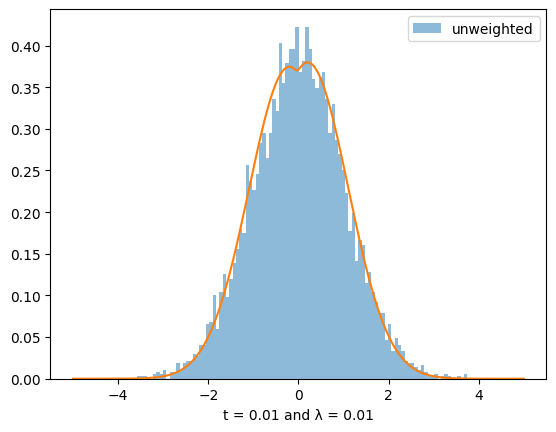

(5000, 1) particles
empirical expectation 0.9939761


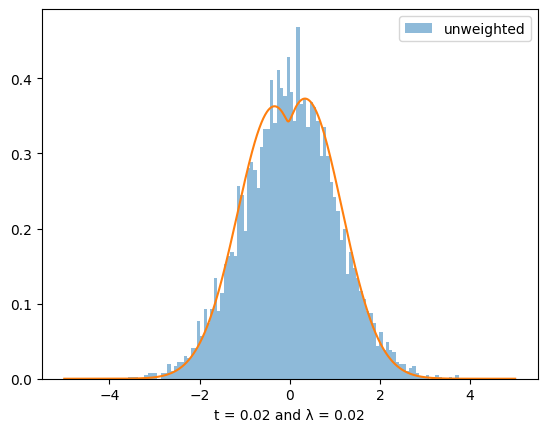

(5000, 1) particles
empirical expectation 0.993835


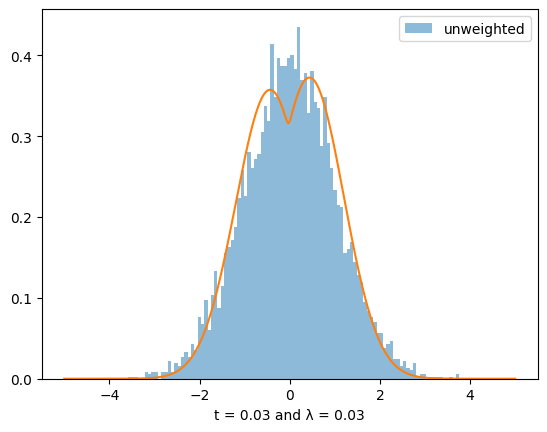

(5000, 1) particles
empirical expectation 0.99337274


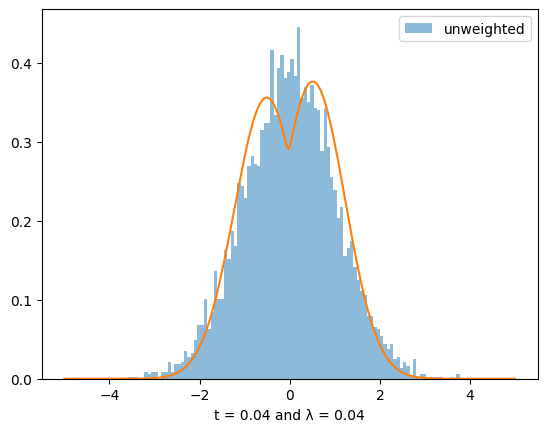

(5000, 1) particles
empirical expectation 0.99374986


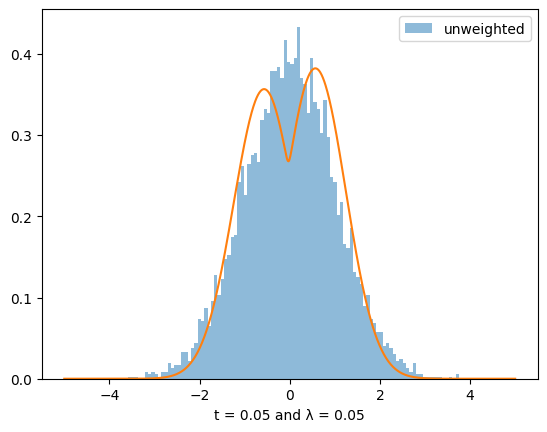

(5000, 1) particles
empirical expectation 0.9932853


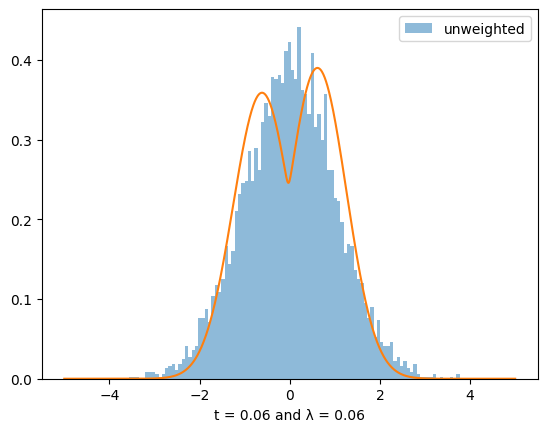

(5000, 1) particles
empirical expectation 0.9936455


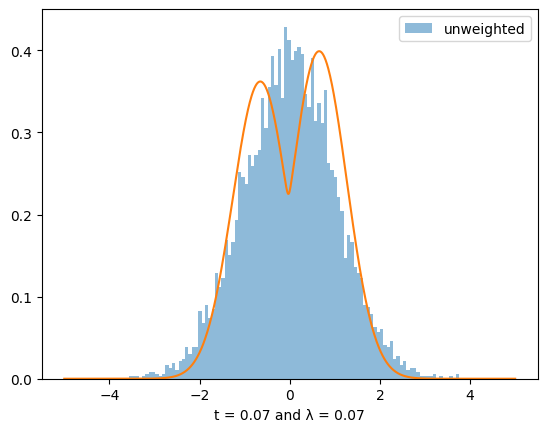

(5000, 1) particles
empirical expectation 0.99330825


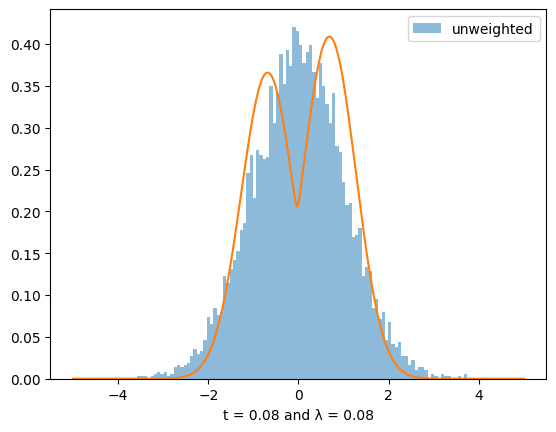

(5000, 1) particles
empirical expectation 0.9932926


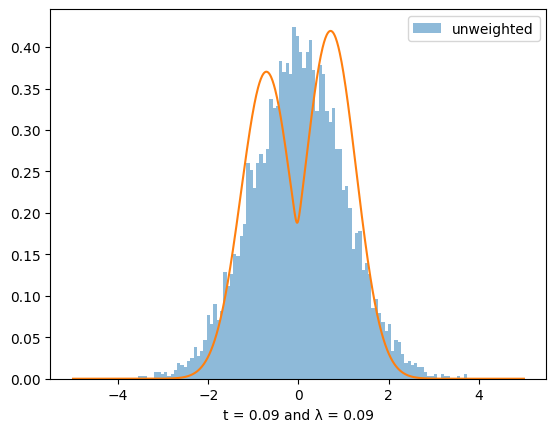

(5000, 1) particles
empirical expectation 0.993814


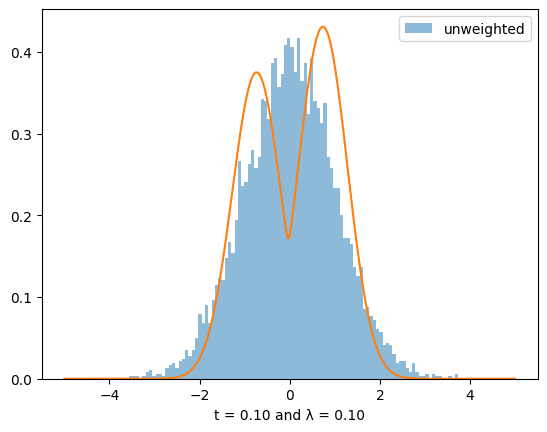

cost: 55000


<Figure size 640x480 with 0 Axes>

In [5]:
# plot a gaussian with unit variance, 1D
import numpy as np
import matplotlib.pyplot as plt
from src.systems import SYSTEMS
import jax.numpy as jnp
# y is a normal pdf (scipy) with std 0.1
from scipy.stats import norm
from src.utils import compute_ess, compute_expectation_over_equilibrium, normalize_log_weights
# y = norm.pdf(x, 0, 1/0.5)



def make_hist(file, system_name, use_weights=True):
    data = pickle.load(open(file, 'rb'))

    x = np.linspace(-5, 5, 1000)

    print(data['snapshots'].keys())

    times = data['snapshots']['times']
    # lambdas = times 
    N = len(times)
    M = data['snapshots']['qs'][0].shape[0]
    lambdas = data['snapshots']['lam']
    # print(lambdas)
    # raise Exception("stop")
    # esses = []
    for i in range(len(data['snapshots']['qs'])):
    # for i in range(1):
        potential = SYSTEMS[system_name]['make_V'](lambdas[i])


        # y = potential(x)
        # print(potential(1))
        # raise Exception("stop")
        # normalize y using trapezoid integration
        rho = np.array([np.exp(-potential(point)) for point in x])
        rho = rho / np.trapz(rho, x)  # Normalize

        # print(times[i])

        # particles = data['snapshots']['particles_before_resampling'][i]
        # log_weights = data['snapshots']['weights_before_resampling'][i]
        qs = data['snapshots']['qs'][i]
        weights = data['snapshots']['weights'][i]
        print(qs.shape, "particles")

        
        all_weights = np.exp(data['snapshots']['weights'])
        all_weights = jnp.clip(all_weights, 0, 1).mean(axis=-1)


        # compute ess of weights 
        # ess = compute_ess(log_weights)
        # print(ess)
        # esses.append(ess)

        # expect = jnp.sum(weights * (particles**2)[:, 0], axis=0)
        # print(expect, "expectation", weights.shape, particles.shape, (weights * (particles**2)[:, 0]).shape)

        empirical_e = compute_expectation_over_equilibrium(qs[:, 0]**2, np.log(weights))
        print("empirical expectation",empirical_e)

        # all_weights = all_weights.mean(axis=-1)
        
        num_bins = 100
        if use_weights: plt.hist(qs[:,0], bins=num_bins, weights=weights, density=True, alpha=0.5, label='weighted')
        plt.hist(qs[:,0], bins=num_bins, density=True, alpha=0.5, label='unweighted')
        plt.plot(x, rho)
        plt.xlabel(f't = {times[i]:.2f} and λ = {lambdas[i][0]:.2f}')
        plt.legend()
        plt.show()
        plt.clf()

        ps = data['snapshots']['ps'][i]

        # scatterplot of qs and ps
        # plt.scatter(qs[:,0], ps[:,0])
        # plt.show()


    # plt.plot(all_weights)
    # print(data)
    # plt.show()
    # plt.plot(esses)

    true_expectation = 0.1
    error = ((empirical_e - true_expectation)**2) / (2 * true_expectation)
    # print(f'error: {error} and ESS: {100/error}')
    cost_per_step = 1
    cost = cost_per_step * N * M 
    print(f'cost: {cost}')



# error_cd, estimate_cd = calculate_normalized_error(
#                     final_samples_cd, true_exp, true_var, f_func
#                 )


# system_name = 'gaussian_annealing'
system_name = 'mixture'
# system_name = 'gaussian_moving_mean'
ansatz = 'naive'
# ansatz = 'neural_network'
# ansatz = 'polynomial'
weighting = 'unweighted'

# make_hist(file='naive/double_well/leapfrog/naive_weighted.pkl', i=0)
# make_hist(file='naive/double_well/leapfrog/naive_unweighted.pkl', i=20)
# make_hist(file='naive/double_well/leapfrog/naive_weighted.pkl', i=20)
# make_hist(file='polynomial/double_well/leapfrog/cd_unweighted.pkl', i=20)
# make_hist(file='polynomial/double_well/leapfrog/cd_weighted.pkl', i=20)


# make_hist(file=f'polynomial/{system_name}/leapfrog/cd_weighted.pkl', system_name=system_name)
make_hist(file=f'{ansatz}/{system_name}/leapfrog/{weighting}.pkl', system_name=system_name, use_weights=weighting=='weighted')
# make_hist(file=f'mixture_smc_adjusted_hmc.pkl', system_name=system_name)

# make_hist(file=f'naive/{system_name}/leapfrog/naive_weighted.pkl', system_name=system_name)



In [102]:
import sys
sys.path.append(".")
sys.path.append("../src")
import os
print(os.listdir("../src"))
from src.plotting import compute_weighted_kde, create_ridge_plot
import jax.numpy as jnp
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import equinox as eqx
import os
from scipy.stats import gaussian_kde
from utils import normalize_log_weights
import jax

def create_ridge_plot(snapshots, make_V, potential_name="harmonic", ansatz_type="polynomial", plot_dir=None, show=False, ax=None, title=None, color=None):
    """
    Create a ridge plot of distributions over time.
    
    Parameters:
    -----------
    snapshots : dict
        Dictionary with 'qs', 'times', 'lam' keys
    make_V : callable
        Function to create potential
    ax : matplotlib.axes.Axes, optional
        Axes to plot on. If None, creates a new figure.
    title : str, optional
        Title for the plot. If None, uses default.
    
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The figure object
    """
    if ax is None:
        fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))
    else:
        ax1 = ax
        fig = ax1.figure
    ax1_lambda = ax1.twinx()
    
    
    # One column: CD only
    plot_title = title if title is not None else "Counterdiabatic HMC Evolution"
    ax1.set_title(plot_title, fontsize=14, fontweight='bold')
    ax1.set_xlabel("Position q", fontsize=12)
    ax1.set_ylabel("p(q)", fontsize=12)
    # ax1_lambda.set_ylabel("λ", fontsize=12, color='red')
    ax1_lambda.tick_params(axis='y', labelcolor='red')
    
    # Find global range for consistent x-axis
    all_qs = np.concatenate(snapshots['qs']).flatten()
    x_min = np.min(all_qs) - 0.25
    x_max = np.max(all_qs) + 0.25
    
    # Create x grid for smooth curves
    x_grid = np.linspace(x_min, x_max, 200)
    
    # Note: Naive HMC plotting removed since naive HMC is not performed in run_simulation
    
    # Note: Naive HMC weighted plotting removed since naive HMC is not performed in run_simulation

    times = snapshots['times']
    print(times, "times")
    times = np.array([0.0,0.5,1.0])
    lambda_values = snapshots['lam']
    
    scale = 1.2
    # Plot CD HMC distributions
    cd_ax = ax1  # Use appropriate axis based on layout
    offsets = []
    for i, (t, cd_snap, lam_val) in enumerate(zip(times, snapshots['qs'], snapshots['lam'])):
        # Compute KDE for smooth curve
        # density = compute_weighted_kde(cd_snap.flatten(), weights=None, x_grid=x_grid)
        
        # Normalize and offset for ridge plot - increased height for more overlap
        # density = density / np.max(density) * scale  # Increased from 1.2 to 1.8 for more overlap
        offset = t * 0.75  # Visual spacing for ridge plots
        offsets.append(offset)
        hist, bin_edges = np.histogram(snapshots['qs'][i], bins=50, density=True, 
                                              range=(np.min(x_grid), np.max(x_grid)))
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        bin_width = bin_edges[1] - bin_edges[0]
        
        # Plot histogram bars instead of smooth curve
        cd_ax.bar(bin_centers, hist, width=bin_width, bottom=offset,
                 color=color, alpha=0.4, edgecolor=color, linewidth=0.5)
        
        # Add true distribution at each time step
        potential_fn = make_V(lam_val)
        rho = np.array(jax.vmap(lambda x: jnp.exp(-potential_fn(x)))(x_grid))
        rho = rho / np.trapz(rho, x_grid) 
        cd_ax.plot(x_grid, offset + rho, 'k--', linewidth=1.5, alpha=0.8)
    
    # Note: Duplicate CD plotting section removed
    
    # Set consistent limits (simplified - only CD-HMC)
    ax1.set_xlim(x_min, x_max)
    offsets = np.array(offsets)
    # Calculate max density to set appropriate y-limits
    max_densities = []
    for i in range(len(snapshots['qs'])):
        hist, _ = np.histogram(snapshots['qs'][i], bins=50, density=True, 
                               range=(np.min(x_grid), np.max(x_grid)))
        max_densities.append(np.max(hist))
    max_density = max(max_densities) if max_densities else 1.0
    ax1.set_ylim(offsets[0] - 0.1, offsets[-1] + max_density + 0.5)
    
   
    # Set y-axis ticks at the offset positions where distributions are plotted
    ax1.set_yticks(offsets)
    ax1.set_yticklabels([f"t={t:.2f}" for t in times])
  
    # Configure lambda axes (secondary y-axes)
    # Configure lambda axes based on layout
    ax1_lambda.set_ylim(ax1.get_ylim())  # Same limits as main axis
    ax1_lambda.set_yticks(offsets)
    # Format lambda values properly
    lambda_tick_labels = []
    for lam in lambda_values:
        # Convert to numpy array first (handles both numpy and JAX arrays)
        lam_np = np.asarray(lam)
        # Extract scalar value
        if lam_np.ndim == 0:
            # Scalar array
            val = float(lam_np.item())
        elif lam_np.ndim > 0 and len(lam_np) > 0:
            # Array - take first element and convert to scalar
            val = float(np.asarray(lam_np[0]).item())
        else:
            val = 0.0
        lambda_tick_labels.append(f"$\lambda$ = {val:.2f}")
    ax1_lambda.set_yticklabels(lambda_tick_labels)
    
    # Note: Removed ax3_lambda configuration since we only have 2 axes now
    
    # Add legends with true distribution reference
    ax1.plot([], [], 'k--', linewidth=1.5)
    # ax1.legend(loc='upper right')
    
    return fig



# Adjust layout and save
# plt.tight_layout()
# plt.show()
# plt.close()
# snapshots.keys()

['simulation.py', 'systems.py', 'ansatze.py', 'simple_benchmark.py', 'adiabatic.py', 'plotting.py', '__init__.py', '__pycache__', 'physics.py', 'utils.py', 'blackjax_smc.py', 'figures', 'fitting.py']


[0.   0.05 0.1 ] times
[0.   0.05 0.1 ] times
[0.  0.5 1. ] times
[0.  0.5 1. ] times


/var/folders/v9/977m2z015_b794hqf_nk0q1r0000gn/T/ipykernel_10052/830474807.py:94: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  rho = rho / np.trapz(rho, x_grid)
/var/folders/v9/977m2z015_b794hqf_nk0q1r0000gn/T/ipykernel_10052/830474807.py:94: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  rho = rho / np.trapz(rho, x_grid)
/var/folders/v9/977m2z015_b794hqf_nk0q1r0000gn/T/ipykernel_10052/830474807.py:94: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  rho = rho / np.trapz(rho, x_grid)
/var/folders/v9/977m2z015_b794hqf_nk0q1r0000gn/T/ipykernel_10052/830474807.py:94: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  rho = rho / np.tra

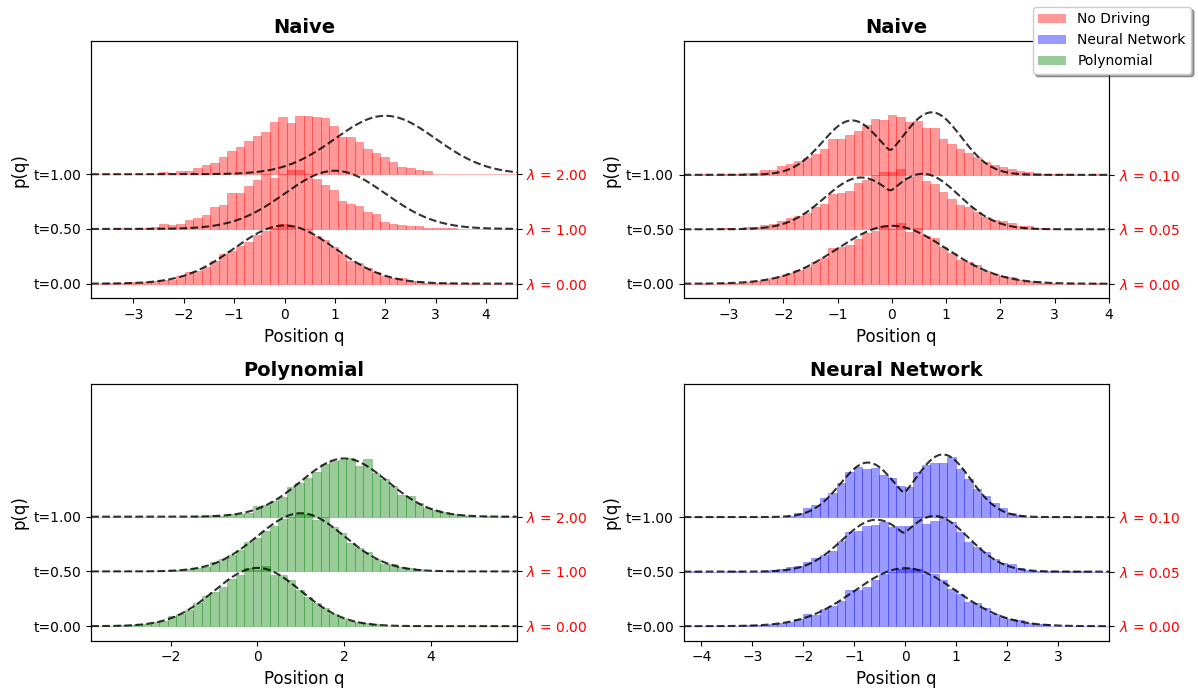

In [103]:
# Create figure with two subplots side by side
fig, ((ax1, ax3), (ax4,  ax6)) = plt.subplots(2, 2, figsize=(12, 7))

# Plot neural_network
ansatz = 'neural_network'
system_name = 'mixture'
snapshots_nn = pickle.load(open(f'{ansatz}/{system_name}/leapfrog/{weighting}.pkl', 'rb'))['snapshots']
snapshots_nn = {
    'qs' : snapshots_nn['qs'][::5],
    'times' : np.array(snapshots_nn['times'][::5]),
    'lam' : snapshots_nn['lam'][::5],
}
fig_nn = create_ridge_plot(
    snapshots=snapshots_nn, 
    make_V=SYSTEMS[system_name]['make_V'],
    ax=ax6,
    title='Neural Network',
    color='blue'
)

# Plot naive
ansatz = 'naive'
snapshots_naive = pickle.load(open(f'{ansatz}/{system_name}/leapfrog/{weighting}.pkl', 'rb'))['snapshots']
snapshots_naive = {
    'qs' : snapshots_naive['qs'][::5],
    'times' : np.array(snapshots_naive['times'][::5]),
    'lam' : snapshots_naive['lam'][::5],
}
fig_naive = create_ridge_plot(
    snapshots=snapshots_naive, 
    make_V=SYSTEMS[system_name]['make_V'],
    ax=ax3,
    title='Naive',
    color='red'
)

ansatz = 'naive'
system_name = 'gaussian_moving_mean'
snapshots_naive = pickle.load(open(f'{ansatz}/{system_name}/leapfrog/{weighting}.pkl', 'rb'))['snapshots']
snapshots_naive = {
    'qs' : snapshots_naive['qs'][::5],
    'times' : np.array(snapshots_naive['times'][::5]),
    'lam' : snapshots_naive['lam'][::5],
}
fig_naive = create_ridge_plot(
    snapshots=snapshots_naive, 
    make_V=SYSTEMS[system_name]['make_V'],
    ax=ax1,
    title='Naive',
    color='red'
)

ansatz = 'polynomial'
system_name = 'gaussian_moving_mean'
snapshots_polynomial = pickle.load(open(f'{ansatz}/{system_name}/leapfrog/{weighting}.pkl', 'rb'))['snapshots']
snapshots_polynomial = {
    'qs' : snapshots_polynomial['qs'][::5],
    'times' : np.array(snapshots_polynomial['times'][::5]),
    'lam' : snapshots_polynomial['lam'][::5],
}
create_ridge_plot(
    snapshots=snapshots_polynomial, 
    make_V=SYSTEMS[system_name]['make_V'],
    ax=ax4,
    title='Polynomial',
    color='green'
)

# add legend to the whole figure mapping colors to ansatz types
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', alpha=0.4, label='No Driving'),
    Patch(facecolor='blue', alpha=0.4, label='Neural Network'),
    Patch(facecolor='green', alpha=0.4, label='Polynomial')
]
fig.legend(handles=legend_elements, loc='upper right', frameon=True, fancybox=True, shadow=True)

    
plt.tight_layout()
plt.show()

<class 'dict'>


/var/folders/v9/977m2z015_b794hqf_nk0q1r0000gn/T/ipykernel_10052/2946341113.py:69: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  rho = rho / np.trapz(rho, x_grid)


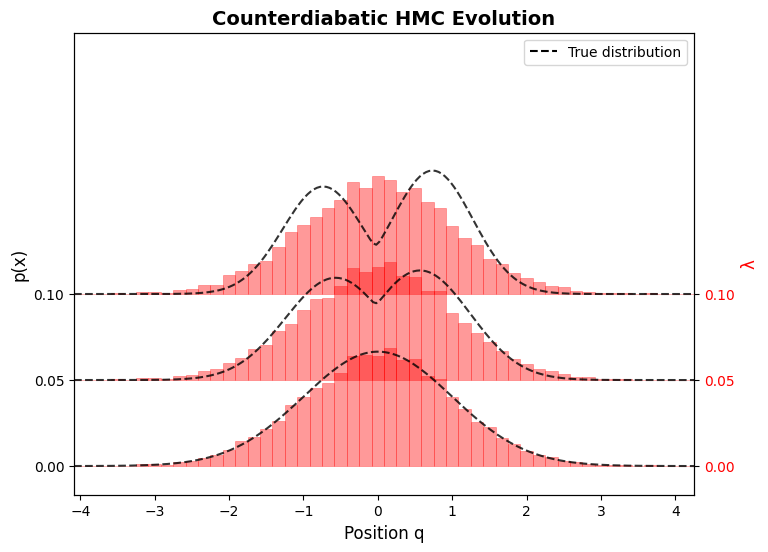

In [ ]:

# This cell is now combined with cell 3 above
# The side-by-side comparison is created in cell 3

In [ ]:
from src.simple_benchmark import calculate_double_well_expectations

    
true_expectations = calculate_double_well_expectations(2.0)
true_expectations

{'x_squared': {'expectation': 14.6827908, 'variance': 17.694268}}

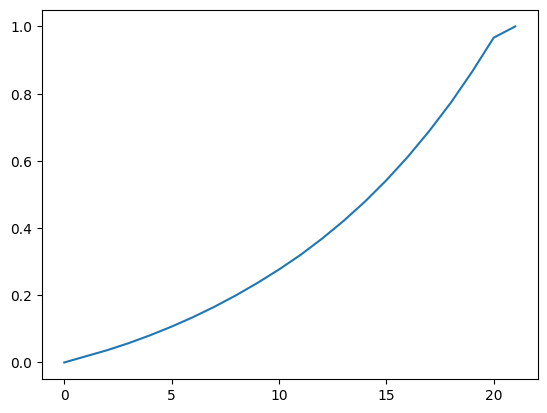

In [23]:
schedule = [0.0, 0.018310546875, 0.036585405468940735, 0.05751897394657135, 0.08098895847797394, 0.10679127275943756, 0.13503114879131317, 0.1660737246274948, 0.19997233152389526, 0.23688766360282898, 0.27675729990005493, 0.32001766562461853, 0.36832696199417114, 0.42091497778892517, 0.4785972833633423, 0.542245090007782, 0.6122046709060669, 0.6890820860862732, 0.77288419008255, 0.8658154010772705, 0.966715931892395, 1.0]

plt.plot(schedule)